In [1]:
# =========================
# Imports
# =========================

import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# =========================
# Device
# =========================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cpu


In [2]:
# =========================
# Model Configuration
# =========================

ARABERT_MODEL = "aubmindlab/bert-base-arabertv2"

BERT_MAX_LEN = 64
BERT_BATCH = 16
BERT_EPOCHS = 3
BERT_LR = 2e-5

RANDOM_STATE = 42

print(f"Model: {ARABERT_MODEL}")
print(f"Max length: {BERT_MAX_LEN}")
print(f"Batch size: {BERT_BATCH}")
print(f"Learning rate: {BERT_LR}")
print(f"Epochs: {BERT_EPOCHS}")

Model: aubmindlab/bert-base-arabertv2
Max length: 64
Batch size: 16
Learning rate: 2e-05
Epochs: 3


In [4]:
# =========================
# Load Dataset
# =========================

DATA_PATH = "../data/raw/CompanyReviews.csv"

df = pd.read_csv(DATA_PATH)
df = df.rename(columns={'review_description': 'text', 'rating': 'sentiment'})
df = df[['text', 'sentiment', 'company']]

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (40046, 3)

Columns:
['text', 'sentiment', 'company']


,text,sentiment,company
0,رائع,1,talbat
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat


In [5]:
# =========================
# Basic EDA
# =========================

print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

Dataset shape: (40046, 3)

Data types:
text           str
sentiment    int64
company        str
dtype: object

Missing values:
text         1
sentiment    0
company      0
dtype: int64

Duplicates:
28


In [6]:
# =========================
# Sentiment Distribution
# =========================

label_names = {
    -1: "Negative",
     0: "Neutral",
     1: "Positive"
}

df["sentiment_label"] = df["sentiment"].map(label_names)

print("Sentiment distribution:")
print(df["sentiment_label"].value_counts())

print("\nSentiment percentage:")
print(
    df["sentiment_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Sentiment distribution:
sentiment_label
Positive    23921
Negative    14200
Neutral      1925
Name: count, dtype: int64

Sentiment percentage:
sentiment_label
Positive    59.73
Negative    35.46
Neutral      4.81
Name: proportion, dtype: float64


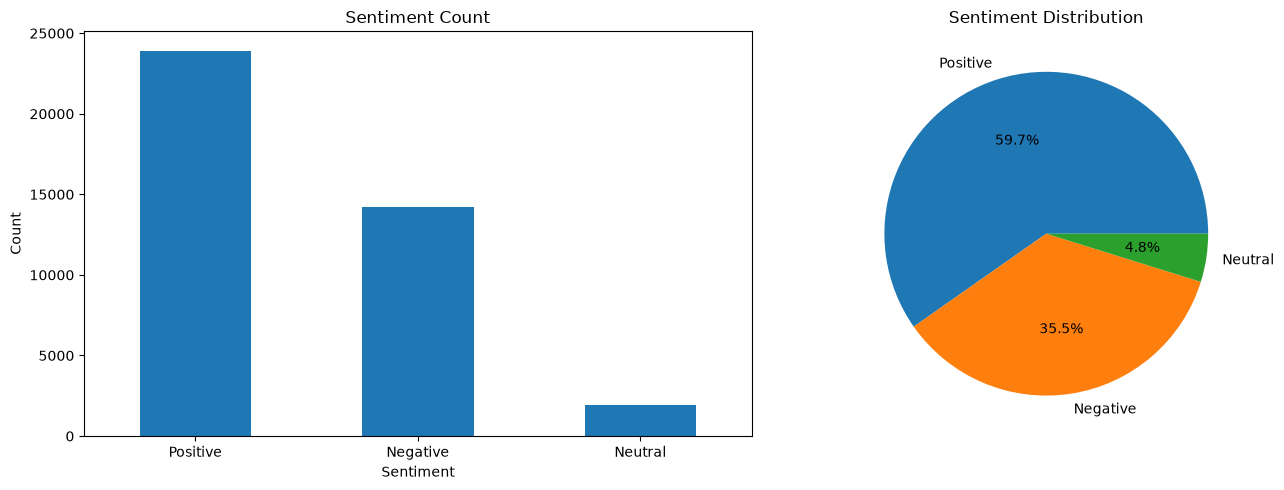

In [7]:
# =========================
# Sentiment Visualization
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts = df["sentiment_label"].value_counts()

sentiment_counts.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Sentiment Count")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

sentiment_counts.plot(
    kind="pie",
    ax=axes[1],
    autopct="%1.1f%%"
)

axes[1].set_title("Sentiment Distribution")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

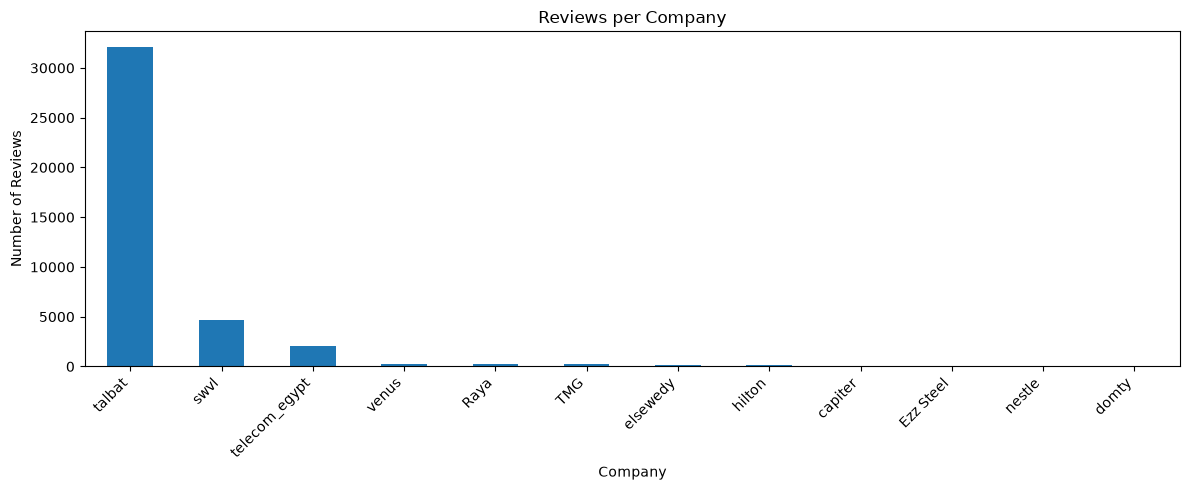

In [8]:
# =========================
# Reviews per Company
# =========================

plt.figure(figsize=(12, 5))

df["company"].value_counts().plot(
    kind="bar"
)

plt.title("Reviews per Company")
plt.xlabel("Company")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [9]:
# =========================
# Basic Text Cleaning
# =========================

df = df.dropna(
    subset=["text", "sentiment"]
).copy()

print("After dropping nulls:", df.shape)


def clean_arabic_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove mentions
    text = re.sub(r"@\w+", " ", text)

    # Normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["text"].apply(clean_arabic_text)

# Remove empty texts
df = df[
    df["clean_text"].str.strip().ne("")
].copy()

print("After removing empty texts:", df.shape)

display(
    df[["text", "clean_text", "sentiment_label"]].head()
)

After dropping nulls: (40045, 4)
After removing empty texts: (40043, 5)


,text,clean_text,sentiment_label
0,رائع,رائع,Positive
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,Positive
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,Negative
3,لماذا لا يمكننا طلب من ماكدونالدز؟,لماذا لا يمكننا طلب من ماكدونالدز؟,Negative
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,Negative


In [10]:
# =========================
# Remove Duplicates
# =========================

before = len(df)

df = df.drop_duplicates(
    subset=["clean_text", "sentiment"]
).reset_index(drop=True)

after = len(df)

print(f"Removed duplicates: {before - after:,}")
print(f"Remaining samples: {after:,}")

Removed duplicates: 1,011
Remaining samples: 39,032


In [11]:
# =========================
# Label Encoding
# =========================

le = LabelEncoder()

df["label"] = le.fit_transform(df["sentiment"])

print("Original classes:")
print(le.classes_)

print("\nLabel mapping:")

label2id = {
    str(label): int(i)
    for i, label in enumerate(le.classes_)
}

id2label = {
    int(i): str(label)
    for i, label in enumerate(le.classes_)
}

print(label2id)
print(id2label)

Original classes:
[-1  0  1]

Label mapping:
{'-1': 0, '0': 1, '1': 2}
{0: '-1', 1: '0', 2: '1'}


In [12]:
# =========================
# Train / Validation / Test Split
# =========================

X = df["clean_text"]
y = df["label"]

# 80% Train, 20% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Split temporary into 10% Validation + 10% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Train:      {len(X_train):,}")
print(f"Validation: {len(X_val):,}")
print(f"Test:       {len(X_test):,}")

Train:      31,225
Validation: 3,903
Test:       3,904


In [13]:
# =========================
# Development Subset
# =========================

TRAIN_N = min(30_000, len(X_train))
VAL_N = min(4_000, len(X_val))
TEST_N = min(8_000, len(X_test))

Xb_train = X_train.iloc[:TRAIN_N].reset_index(drop=True)
yb_train = y_train.iloc[:TRAIN_N].reset_index(drop=True)

Xb_val = X_val.iloc[:VAL_N].reset_index(drop=True)
yb_val = y_val.iloc[:VAL_N].reset_index(drop=True)

Xb_test = X_test.iloc[:TEST_N].reset_index(drop=True)
yb_test = y_test.iloc[:TEST_N].reset_index(drop=True)

print(f"Train subset: {len(Xb_train):,}")
print(f"Validation subset: {len(Xb_val):,}")
print(f"Test subset: {len(Xb_test):,}")

Train subset: 30,000
Validation subset: 3,903
Test subset: 3,904


In [14]:
# =========================
# Class Weights
# =========================

classes = np.unique(yb_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=yb_train
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float
).to(DEVICE)

print("Class weights:")

for class_id, weight in zip(classes, class_weights):
    print(
        f"{class_id} "
        f"({id2label[int(class_id)]}): "
        f"{weight:.3f}"
    )

Class weights:
0 (-1): 0.933
1 (0): 6.803
2 (1): 0.562


In [15]:
# =========================
# Tokenizer
# =========================

tokenizer = AutoTokenizer.from_pretrained(
    ARABERT_MODEL
)

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [16]:
# =========================
# PyTorch Dataset
# =========================

class ArabertDataset(Dataset):

    def __init__(self, texts, labels):
        self.texts = texts.tolist()
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = tokenizer(
            self.texts[idx],
            max_length=BERT_MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }

In [17]:
# =========================
# DataLoaders
# =========================

train_dataset = ArabertDataset(
    Xb_train,
    yb_train
)

val_dataset = ArabertDataset(
    Xb_val,
    yb_val
)

test_dataset = ArabertDataset(
    Xb_test,
    yb_test
)


bert_train_loader = DataLoader(
    train_dataset,
    batch_size=BERT_BATCH,
    shuffle=True,
    pin_memory=torch.cuda.is_available()
)

bert_val_loader = DataLoader(
    val_dataset,
    batch_size=BERT_BATCH,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

bert_test_loader = DataLoader(
    test_dataset,
    batch_size=BERT_BATCH,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(bert_train_loader))
print("Validation batches:", len(bert_val_loader))
print("Test batches:", len(bert_test_loader))

Train batches: 1875
Validation batches: 244
Test batches: 244


In [18]:
# =========================
# Load AraBERT
# =========================

NUM_CLASSES = len(le.classes_)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    ARABERT_MODEL,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id
)

bert_model = bert_model.to(DEVICE)

print("AraBERT model loaded.")
print("Number of classes:", NUM_CLASSES)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 450.28it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from 

AraBERT model loaded.
Number of classes: 3


In [19]:
# =========================
# Loss / Optimizer / Scheduler
# =========================

bert_criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer_b = AdamW(
    bert_model.parameters(),
    lr=BERT_LR,
    eps=1e-8
)

total_steps = (
    len(bert_train_loader) * BERT_EPOCHS
)

scheduler = get_linear_schedule_with_warmup(
    optimizer_b,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps
)

print("Total training steps:", total_steps)

Total training steps: 5625


In [20]:
# =========================
# Training Function
# =========================

def bert_train_epoch(model, loader):

    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch in progress:

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer_b.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = bert_criterion(
            outputs.logits,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer_b.step()
        scheduler.step()

        predictions = outputs.logits.argmax(dim=1)

        total_loss += loss.item()

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = total_correct / total_samples

    return avg_loss, accuracy

In [21]:
# =========================
# Evaluation Function
# =========================

def bert_evaluate(model, loader):

    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        progress = tqdm(
            loader,
            desc="Evaluating",
            leave=False
        )

        for batch in progress:

            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = bert_criterion(
                outputs.logits,
                labels
            )

            predictions = outputs.logits.argmax(dim=1)

            total_loss += loss.item()

            total_correct += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    avg_loss = total_loss / len(loader)
    accuracy = total_correct / total_samples

    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return (
        avg_loss,
        accuracy,
        f1,
        all_predictions,
        all_labels
    )

In [22]:
# =========================
# Training
# =========================

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": []
}

print("Training AraBERT...\n")

for epoch in range(1, BERT_EPOCHS + 1):

    train_loss, train_acc = bert_train_epoch(
        bert_model,
        bert_train_loader
    )

    val_loss, val_acc, val_f1, _, _ = bert_evaluate(
        bert_model,
        bert_val_loader
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch}/{BERT_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

Training AraBERT...



Epoch 1/3 | Train Loss: 0.7939 | Train Acc: 0.7687 | Val Loss: 0.7383 | Val Acc: 0.8281 | Val F1: 0.6490


Epoch 2/3 | Train Loss: 0.6586 | Train Acc: 0.8261 | Val Loss: 0.7159 | Val Acc: 0.8265 | Val F1: 0.6662


Epoch 3/3 | Train Loss: 0.5613 | Train Acc: 0.8599 | Val Loss: 0.7998 | Val Acc: 0.8329 | Val F1: 0.6714


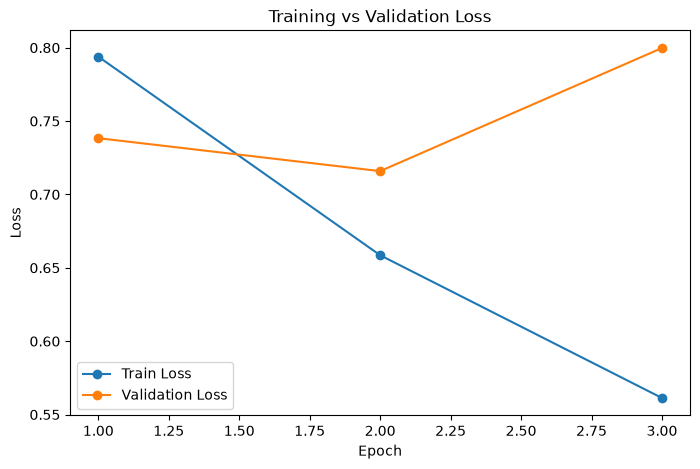

In [23]:
# =========================
# Training Curves
# =========================

epochs = range(1, BERT_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [24]:
# =========================
# Final Test Evaluation
# =========================

test_loss, test_acc, test_f1, y_pred, y_true = bert_evaluate(
    bert_model,
    bert_test_loader
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Macro: {test_f1:.4f}")

Test Loss: 0.7813
Test Accuracy: 0.8340
Test F1-Macro: 0.6730


In [25]:
# =========================
# Classification Report
# =========================

target_names = [
    id2label[i]
    for i in range(NUM_CLASSES)
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=4
    )
)

              precision    recall  f1-score   support

          -1     0.8449    0.8315    0.8382      1395
           0     0.2353    0.3770    0.2897       191
           1     0.9097    0.8732    0.8910      2318

    accuracy                         0.8340      3904
   macro avg     0.6633    0.6939    0.6730      3904
weighted avg     0.8535    0.8340    0.8427      3904



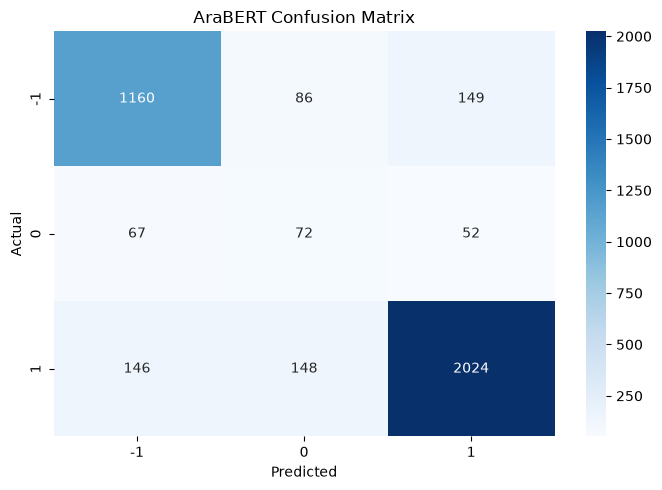

: 

In [ ]:
# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("AraBERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()